In [56]:
import os
from dotenv import load_dotenv
from pyprojroot import here
load_dotenv()

True

1 -> RAG TOOL

In [57]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.tools import tool


EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
VECTORDB_DIR = "data/airline_policy_vectordb"
K=2


In [58]:
@tool
def lookup_policy(query: str)->str:
    """Consult the company policies to check whether certain options are permitted."""
    vectordb = Chroma(
    collection_name="rag-chroma",
    persist_directory=str(here(VECTORDB_DIR)),
    embedding_function=HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)
    )
    docs = vectordb.similarity_search(query, k=K)
    return "\n\n".join([doc.page_content for doc in docs])

print(lookup_policy)

name='lookup_policy' description='Consult the company policies to check whether certain options are permitted.' args_schema=<class 'langchain_core.utils.pydantic.lookup_policy'> func=<function lookup_policy at 0x000002362AE58720>


In [59]:
lookup_policy.invoke("can i cancel my ticket")

'for a refund or may only be able to receive a partial refund. If you booked your flight through a third-party website or\ntravel agent, you may need to contact them directly to cancel your flight. Always check the terms and conditions of your\nticket to make sure you understand the cancellation policy and any associated fees or penalties. If you\'re cancelling your\nflight due to unforeseen circumstances such as a medical emergency or a natural disaster, Swiss Air may offer you\nspecial exemptions or accommodations. What is Swiss Airlines 24 Hour Cancellation Policy? Swiss Airlines has a 24\n\nhour cancellation policy that allows passengers to cancel their flights within 24 hours of booking at +1-877-507-7341\nwithout penalty. This policy applies to all fare types, including non-refundable tickets. If you cancel your Swiss Airlines\nflight within 24 hours of booking, you\'ll receive a full refund of your ticket price.\nHow to Cancel Swiss Airlines Flight within 24 Hours? If you need t

2-> Search Design Tool

In [ ]:
from langchain_community.tools.tavily_search import TavilySearch
search_tool = TavilySearch(max_results = 2)

In [61]:
search_tool.invoke('whats a node in langgraph?')

[{'title': 'Understanding Core Concepts of LangGraph (Deep Dive)',
  'url': 'https://dev.to/raunaklallala/understanding-core-concepts-of-langgraph-deep-dive-1d7h',
  'content': '### 1. Nodes: The Execution Units\n\nA Node is basically “a single action.” Imagine breaking your workday into steps: checking email, making coffee, writing code, or scheduling a meeting. Each of those is a Node.\n\nIn LangGraph, a Node can be many things:\n\n A large language model call (like GPT, Gemini, or LLaMA).\n A tool (search engine lookup, calculator, weather API, database query).\n A custom function (Python function, regex cleaner, summarizer).\n\nEach Node is like a worker with a simple contract: it takes an input, does its piece of the job, and pushes out an output.\n\nEveryday example:  \n  \n Think about ordering food on a delivery app. [...] Skip to content\n\nLog in    Create account\n\n## DEV Community\n\nRaunak ALI\n\nPosted on\n\n# Understanding Core Concepts of LangGraph (Deep Dive)\n\n#lang

3 -> SQL Agents


In [ ]:
import os
from dotenv import load_dotenv
from operator import itemgetter

from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_groq import ChatGroq
from langchain_community.utilities import SQLDatabase
from langchain_community.tools import QuerySQLDataBaseTool
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_classic.chains import create_sql_query_chain  # ⚠️ deprecated but kept as requested
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain.tools import tool
from sqlalchemy import create_engine
from langchain.agents import create_agent
from urllib.parse import quote_plus

load_dotenv()

sql_llm =  ChatGroq(model="openai/gpt-oss-120b")


True

In [63]:
# llm = HuggingFaceEndpoint(
#     model = "google/gemma-2-2b-it",
#     task="text-generation"
# )
# sql_llm = ChatHuggingFace(llm = llm)
sql_llm =  ChatGroq(model="openai/gpt-oss-120b")

In [ ]:
# Read environment variables
host = os.getenv("POSTGRES_HOST")
user = os.getenv("POSTGRES_USER")
password = quote_plus(os.getenv("POSTGRES_PASSWORD"))  # ✅ ENCODE
port = os.getenv("POSTGRES_PORT")
database = os.getenv("POSTGRES_DATABASE")  # ✅ FIXED NAME

# Build connection string
connection_string = (
    f"postgresql+psycopg2://{user}:{password}"
    f"@{host}:{port}/{database}"
)

# Optional: debug once
print("Connecting to:", f"{user}@{host}:{port}/{database}")

# Build engine
engine = create_engine(connection_string)
# db = SQLDatabase(engine=engine)
db_object = SQLDatabase(engine=engine)
tool_kit = SQLDatabaseToolkit(db=db_object, llm=sql_llm)
tools = tool_kit.get_tools()



Connecting to: Aashdit_Technologies@localhost:5432/MainDB


(<langchain_community.utilities.sql_database.SQLDatabase at 0x2362694a610>,
 SQLDatabaseToolkit(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000002362694A610>, llm=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000236271E3410>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000236271E13D0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))))

In [65]:
system_role = """Given the following user question, corresponding SQL query, and SQL result, answer the user question.

Question: {question}
SQL Query: {query}
SQL Result: {result}
Answer:
"""

agent = create_agent(
    model = sql_llm,
    tools=tools
)


In [66]:
# question = "How many departments are present in department table?"

# for step in agent.stream(
#     {"messages": [{"role": "user", "content": question}]}, stream_mode="values"
# ):
#     step["messages"][-1].pretty_print()


@tool
def query_sqldb(question: str) -> str:
    """
    Use this tool when the user asks a question that requires querying
    the SQL database. The tool internally uses an agentic SQL reasoner.
    """
    for step in agent.stream(
        {"messages": [{"role": "user", "content": question}]}, stream_mode="values"
    ):
        step["messages"][-1].pretty_print()

In [67]:
# response = query_sqldb.invoke(
#     "How many departments are present in table named hr_department ?"
# )

# print(response)

In [68]:
tools = [search_tool, lookup_policy, query_sqldb]

In [69]:
# llm = HuggingFaceEndpoint(
#     model = "google/gemma-2-2b-it",
#     task="text-generation"
# )
# model = ChatHuggingFace(llm = llm)
model = ChatGroq(model="openai/gpt-oss-120b")
model_with_tools = model.bind_tools(tools)


 4 -> Initialize Graph

In [70]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [71]:
def chatbot(state:State):
    return {"messages": [model_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot",chatbot)

In [72]:
import json
from langchain_core.messages import ToolMessage


class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}


tool_node = BasicToolNode(tools=[search_tool, lookup_policy, query_sqldb])
graph_builder.add_node("tools", tool_node)

 5 -> Entrypoint and Edges

In [73]:
from typing import Literal


def route_tool(state:State) -> Literal["tools", "__end__"]:
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"
    

graph_builder.add_conditional_edges(
    "chatbot", route_tool, {"tools":"tools","__end__":"__end__"}
)
graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

In [74]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

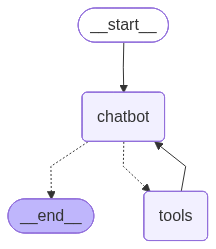

In [75]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [76]:
config = {"configurable" : {"thread_id":"1"}}

In [ ]:
user_input = "Hi there! My name is Kartik."

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Kartik.
================================== Ai Message ==================================

Hello Kartik! 👋 Nice to meet you. How can I assist you today?


In [78]:
user_input = "Can I cancel my ticket 10 hours before the flight?"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Can I cancel my ticket 10 hours before the flight?
================================== Ai Message ==================================
Tool Calls:
  lookup_policy (fc_70e54a2c-68f6-44e3-a3b1-eece3c619826)
 Call ID: fc_70e54a2c-68f6-44e3-a3b1-eece3c619826
  Args:
    query: airline ticket cancellation policy 10 hours before flight
================================= Tool Message =================================
Name: lookup_policy

"hour cancellation policy that allows passengers to cancel their flights within 24 hours of booking at +1-877-507-7341\nwithout penalty. This policy applies to all fare types, including non-refundable tickets. If you cancel your Swiss Airlines\nflight within 24 hours of booking, you'll receive a full refund of your ticket price.\nHow to Cancel Swiss Airlines Flight within 24 Hours? If you need to cancel your Swiss Airlines flight within 24 hours of\nbooking, you can do so easily onl

In [79]:
event

{'messages': [HumanMessage(content='Hi there! My name is Kartik.', additional_kwargs={}, response_metadata={}, id='e3ecbf4f-0e75-4383-a3eb-cc7ecaa04735'),
  AIMessage(content='Hello Kartik! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user just says "Hi there! My name is Kartik." Probably just a greeting. We can respond friendly, ask how can help.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 235, 'total_tokens': 292, 'completion_time': 0.12664714, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.010270608, 'prompt_tokens_details': None, 'queue_time': 0.050498552, 'total_time': 0.136917748}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019bb59a-80c0-7fe3-ab32-015aa6201d85-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token